In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

In [11]:
columns = [
    "age","sex","cp","trestbps","chol","fbs","restecg",
    "thalach","exang","oldpeak","slope","ca","thal","target"
]

df = pd.read_csv("processed.cleveland.csv", names=columns)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [12]:
df.shape

(303, 14)

In [13]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


In [14]:
df.replace("?", np.nan, inplace=True)
df.dropna(inplace=True)

df = df.astype(float)

In [15]:
df["target"] = (df["target"] > 0).astype(int)

In [16]:
x_variables = df.iloc[:, :-1]
x_variables
y_variables = df.iloc[:, -1]
y_variables

,target
0,0
1,1
2,1
3,0
4,0
...,...
297,1
298,1
299,1
300,1


In [17]:
sc = StandardScaler()
transformed_df = sc.fit_transform(x_variables)

transformed_df

array([[ 0.93618065,  0.69109474, -2.24062879, ...,  2.26414539,
        -0.72197605,  0.65587737],
       [ 1.3789285 ,  0.69109474,  0.87388018, ...,  0.6437811 ,
         2.47842525, -0.89422007],
       [ 1.3789285 ,  0.69109474,  0.87388018, ...,  0.6437811 ,
         1.41162482,  1.17257652],
       ...,
       [ 1.48961547,  0.69109474,  0.87388018, ...,  0.6437811 ,
         1.41162482,  1.17257652],
       [ 0.27205887,  0.69109474,  0.87388018, ...,  0.6437811 ,
         0.34482438,  1.17257652],
       [ 0.27205887, -1.44697961, -1.20245913, ...,  0.6437811 ,
         0.34482438, -0.89422007]])

In [18]:
cov_matrix = np.cov(transformed_df.T)
cov_matrix

array([[ 1.00337838e+00, -9.27116394e-02,  1.10844079e-01,
         2.91457601e-01,  2.03328152e-01,  1.32508144e-01,
         1.50422987e-01, -3.95895864e-01,  9.68147803e-02,
         1.97788570e-01,  1.59943266e-01,  3.63434026e-01,
         1.27013654e-01],
       [-9.27116394e-02,  1.00337838e+00,  8.93812118e-03,
        -6.65643227e-02, -1.98758283e-01,  3.89815506e-02,
         3.40113444e-02, -6.07003847e-02,  1.44066322e-01,
         1.06927268e-01,  3.34576164e-02,  9.22353569e-02,
         3.84947868e-01],
       [ 1.10844079e-01,  8.93812118e-03,  1.00337838e+00,
        -3.71046794e-02,  7.23318517e-02, -5.78579173e-02,
         6.41205889e-02, -3.40453934e-01,  3.78800211e-01,
         2.03930459e-01,  1.51588995e-01,  2.36440218e-01,
         2.69406641e-01],
       [ 2.91457601e-01, -6.65643227e-02, -3.71046794e-02,
         1.00337838e+00,  1.31980092e-01,  1.81470555e-01,
         1.49746475e-01, -4.92735683e-02,  6.69163763e-02,
         1.91889227e-01,  1.21581418e

In [19]:
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)
eigen_pairs = [(np.abs(eigen_values[i]), eigen_vectors[:, i])
               for i in range(len(eigen_values))]

for i in eigen_pairs:
    print(i[0])

3.0907639167165586
1.6108569389064091
1.2527158443145976
1.110838419491879
0.3554362258454165
0.40964027226223076
0.4547634099811509
0.569823045045338
0.996310626521856
0.687236430950151
0.7819107881203895
0.876582867766474
0.84704013299648


In [20]:
pca = PCA()
pca = pca.fit(transformed_df)

In [22]:
explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.23695056, 0.12349486, 0.0960383 , 0.0851614 , 0.07638123,
       0.06720242, 0.06493755, 0.05994447, 0.05268635, 0.04368496,
       0.03486402, 0.03140469, 0.02724919])

<Axes: xlabel='Principal Component', ylabel='variance'>

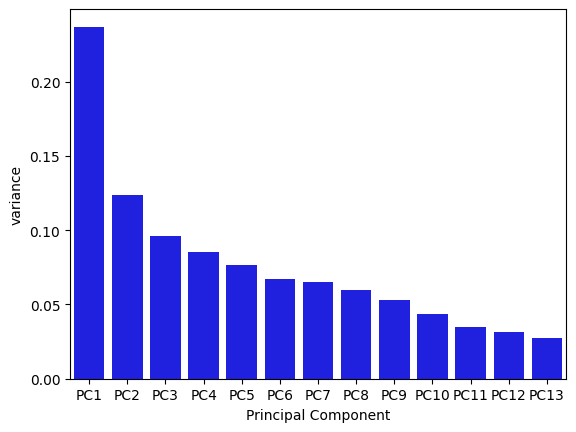

In [23]:
data = pd.DataFrame({
    'variance': pca.explained_variance_ratio_,
    'Principal Component': [f'PC{i+1}' for i in range(len(explained_variance))]
})

sns.barplot(x='Principal Component', y="variance", data=data, color="b")

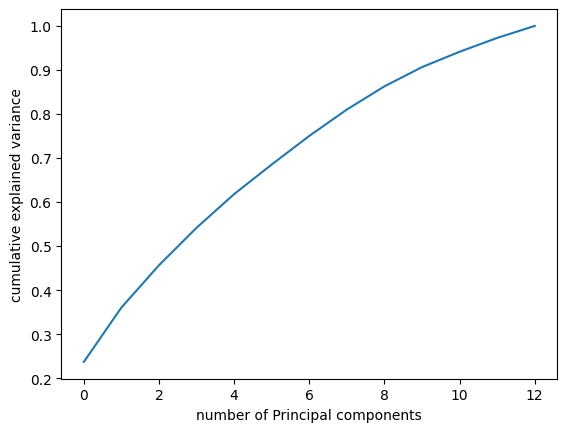

In [24]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of Principal components')
plt.ylabel('cumulative explained variance')
plt.show()

In [25]:
pca_2 = PCA(n_components=2)
pca_2_result = pca_2.fit_transform(transformed_df)
pca_2d = pca_2.transform(transformed_df)

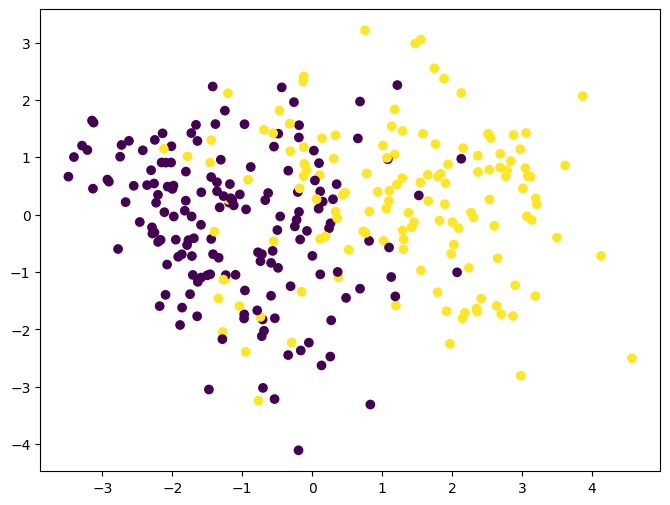

In [26]:
plt.figure(figsize=(8,6))
plt.scatter(pca_2d[:,0], pca_2d[:,1], c=y_variables)
plt.show()